<a href="https://colab.research.google.com/github/ayualfia/PBA-Amazon-SentimentAnalysis/blob/main/week3_amazonshopping_review_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 - Sentiment Analysis Review Aplikasi Amazon Shopping

Notebook ini digunakan untuk melakukan sentiment analysis terhadap dataset review aplikasi Amazon Shopping yang telah melalui tahap preprocessing.

## Tujuan Notebook
1. Membaca dataset hasil preprocessing.
2. Melakukan sentiment analysis menggunakan TextBlob.
3. Menghasilkan nilai `polarity` dan `subjectivity`.
4. Mengklasifikasikan sentimen menjadi Positive, Neutral, dan Negative.
5. Membandingkan hasil sentimen TextBlob dengan rating pengguna.
6. Menampilkan visualisasi hasil sentiment analysis.
7. Menyimpan dataset hasil sentiment analysis ke dalam file CSV.

## Sumber Data
- Aplikasi: Amazon Shopping
- File input: `data/amazon_reviews_preprocessed.csv`
- File output: `data/amazon_reviews_sentiment.csv`

## Catatan
Kolom utama yang digunakan untuk sentiment analysis adalah `final_clean_text`.

In [1]:
# ============================================================
# INSTAL & IMPORT LIBRARY
# ============================================================
!pip install textblob wordcloud tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from textblob import TextBlob
from tqdm.auto import tqdm
from wordcloud import WordCloud

In [2]:
# ============================================================
# KONFIGURASI AWAL
# ============================================================

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Dataset hasil preprocessing dari GitHub
# Pakai media.githubusercontent.com jika file tersimpan dengan Git LFS
DATA_URL = "https://media.githubusercontent.com/media/ayualfia/PBA-Amazon-SentimentAnalysis/main/data/amazon_reviews_preprocessed.csv"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(DATA_DIR, "amazon_reviews_sentiment.csv")

print("Input data:")
print(DATA_URL)

print("\nOutput data:")
print(OUTPUT_PATH)

Input data:
https://media.githubusercontent.com/media/ayualfia/PBA-Amazon-SentimentAnalysis/main/data/amazon_reviews_preprocessed.csv

Output data:
data/amazon_reviews_sentiment.csv


In [3]:
# ============================================================
# LOAD DATASET HASIL PREPROCESSING
# ============================================================

df = pd.read_csv(DATA_URL, low_memory=False)

print("Dataset berhasil dimuat.")
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

df.head()

Dataset berhasil dimuat.
Jumlah baris: 332562
Jumlah kolom: 9


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,final_clean_text,final_stemmed_text
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,compatible android tablet lost mind ever made ...,compat android tablet lost mind ever made deci...
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,keep crashing,keep crash
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,love got new pixel tablet let install personal...,love got new pixel tablet let instal person th...
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49,good service,good servic


In [4]:
# ============================================================
# INFORMASI DATASET
# ============================================================

print("Daftar kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Daftar kolom:
['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'final_clean_text', 'final_stemmed_text']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332562 entries, 0 to 332561
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              332562 non-null  object
 1   userName              332562 non-null  object
 2   content               332562 non-null  object
 3   score                 332562 non-null  int64 
 4   thumbsUpCount         332562 non-null  int64 
 5   reviewCreatedVersion  268183 non-null  object
 6   at                    332562 non-null  object
 7   final_clean_text      332562 non-null  object
 8   final_stemmed_text    332562 non-null  object
dtypes: int64(2), object(7)
memory usage: 22.8+ MB


In [5]:
# ============================================================
# CEK MISSING VALUE
# ============================================================

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

,0
reviewCreatedVersion,64379
reviewId,0
userName,0
score,0
content,0
thumbsUpCount,0
at,0
final_clean_text,0
final_stemmed_text,0


In [6]:
# ============================================================
# MEMASTIKAN KOLOM TEKS TERSEDIA
# ============================================================

text_column = "final_clean_text"

if text_column not in df.columns:
    raise KeyError(f"Kolom '{text_column}' tidak ditemukan. Pastikan file preprocessing sudah benar.")

df[text_column] = df[text_column].fillna("").astype(str)

df[[text_column]].head()

,final_clean_text
0,compatible android tablet lost mind ever made ...
1,cannot complete return android leaf stuck port...
2,keep crashing
3,love got new pixel tablet let install personal...
4,good service


In [7]:
# ============================================================
# MENGHAPUS DATA DENGAN TEKS KOSONG
# ============================================================

before_cleaning = df.shape[0]

df_sentiment = df.copy()
df_sentiment = df_sentiment[df_sentiment[text_column].str.strip() != ""]

after_cleaning = df_sentiment.shape[0]

print("Jumlah data sebelum hapus teks kosong:", before_cleaning)
print("Jumlah data setelah hapus teks kosong:", after_cleaning)
print("Jumlah data yang dihapus:", before_cleaning - after_cleaning)

Jumlah data sebelum hapus teks kosong: 332562
Jumlah data setelah hapus teks kosong: 332562
Jumlah data yang dihapus: 0


In [8]:
# ============================================================
# FUNGSI SENTIMENT ANALYSIS MENGGUNAKAN TEXTBLOB
# ============================================================

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [9]:
# ============================================================
# MENGHITUNG POLARITY DAN SUBJECTIVITY
# ============================================================

tqdm.pandas()

df_sentiment["polarity"] = df_sentiment[text_column].progress_apply(get_polarity)
df_sentiment["subjectivity"] = df_sentiment[text_column].progress_apply(get_subjectivity)

df_sentiment[["content", text_column, "polarity", "subjectivity"]].head()

  0%|          | 0/332562 [00:00<?, ?it/s]

  0%|          | 0/332562 [00:00<?, ?it/s]

,content,final_clean_text,polarity,subjectivity
0,"not compatible with Android tablets , Amazon y...",compatible android tablet lost mind ever made ...,-0.112500,0.125000
1,You cannot complete a return on Android at all...,cannot complete return android leaf stuck port...,0.100000,0.400000
2,app keeps crashing,keep crashing,0.000000,0.000000
3,I love this app for shopping but I just got a ...,love got new pixel tablet let install personal...,0.184091,0.388636
4,GOOD 🥰🥰🥰 service,good service,0.700000,0.600000


In [10]:
# ============================================================
# KLASIFIKASI SENTIMEN BERDASARKAN POLARITY
# ============================================================

df_sentiment["sentiment_textblob"] = df_sentiment["polarity"].apply(classify_sentiment)

df_sentiment[
    ["content", text_column, "polarity", "subjectivity", "sentiment_textblob"]
].head()

,content,final_clean_text,polarity,subjectivity,sentiment_textblob
0,"not compatible with Android tablets , Amazon y...",compatible android tablet lost mind ever made ...,-0.112500,0.125000,Negative
1,You cannot complete a return on Android at all...,cannot complete return android leaf stuck port...,0.100000,0.400000,Positive
2,app keeps crashing,keep crashing,0.000000,0.000000,Neutral
3,I love this app for shopping but I just got a ...,love got new pixel tablet let install personal...,0.184091,0.388636,Positive
4,GOOD 🥰🥰🥰 service,good service,0.700000,0.600000,Positive


In [11]:
# ============================================================
# LABEL SENTIMEN BERDASARKAN RATING
# ============================================================

def classify_rating(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df_sentiment["sentiment_rating"] = df_sentiment["score"].apply(classify_rating)

df_sentiment[
    ["content", "score", "sentiment_rating", "sentiment_textblob"]
].head()

,content,score,sentiment_rating,sentiment_textblob
0,"not compatible with Android tablets , Amazon y...",1,Negative,Negative
1,You cannot complete a return on Android at all...,1,Negative,Positive
2,app keeps crashing,2,Negative,Neutral
3,I love this app for shopping but I just got a ...,3,Neutral,Positive
4,GOOD 🥰🥰🥰 service,5,Positive,Positive


In [12]:
# ============================================================
# DISTRIBUSI SENTIMEN TEXTBLOB
# ============================================================

sentiment_order = ["Positive", "Neutral", "Negative"]

sentiment_counts = df_sentiment["sentiment_textblob"].value_counts().reindex(
    sentiment_order,
    fill_value=0
)

sentiment_percentage = (sentiment_counts / len(df_sentiment) * 100).round(2)

print("Distribusi sentimen berdasarkan TextBlob:")
print(sentiment_counts)

print("\nPersentase sentimen:")
print(sentiment_percentage)

Distribusi sentimen berdasarkan TextBlob:
sentiment_textblob
Positive    194570
Neutral      73318
Negative     64674
Name: count, dtype: int64

Persentase sentimen:
sentiment_textblob
Positive    58.51
Neutral     22.05
Negative    19.45
Name: count, dtype: float64


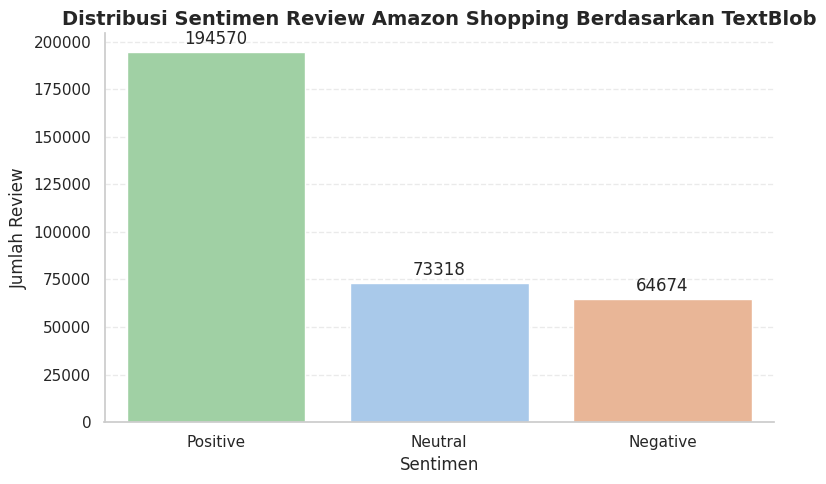

In [55]:
# ============================================================
# VISUALISASI DISTRIBUSI SENTIMEN TEXTBLOB
# ============================================================

sentiment_order = ["Positive", "Neutral", "Negative"]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_sentiment,
    x="sentiment_textblob",
    hue="sentiment_textblob",
    order=sentiment_order,
    hue_order=sentiment_order,
    palette={
        "Positive": "#98D89E",
        "Negative": "#F6B38A",
        "Neutral": "#9EC9F5"
    },
    legend=False
)

plt.title("Distribusi Sentimen Review Amazon Shopping Berdasarkan TextBlob", fontsize=14, fontweight="bold")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

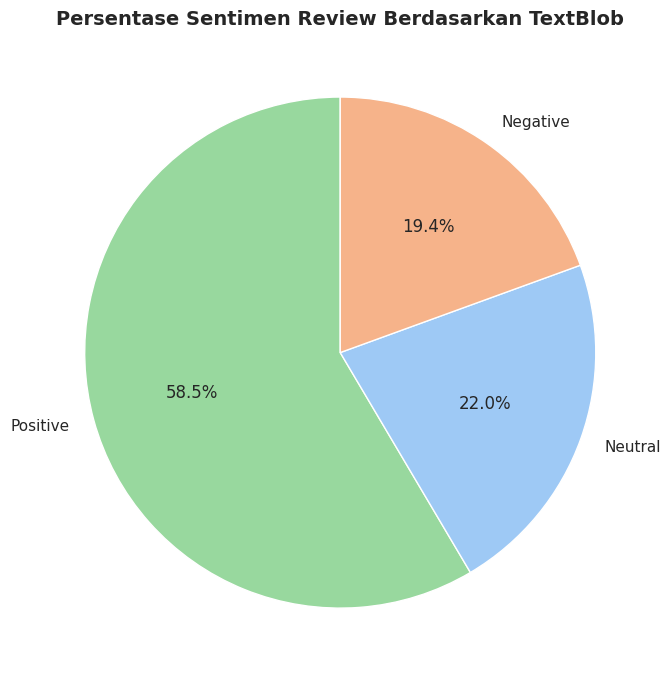

In [54]:
# ============================================================
# PIE CHART PERSENTASE SENTIMEN
# ============================================================

sentiment_order = ["Positive", "Neutral", "Negative"]

sentiment_counts = df_sentiment["sentiment_textblob"].value_counts().reindex(
    sentiment_order,
    fill_value=0
)

plt.figure(figsize=(7, 7))

sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "#98D89E",  # Positive = biru pastel
        "#9EC9F5",  # Neutral = hijau pastel
        "#F6B38A"   # Negative = oranye pastel
    ],
    ylabel=""
)

plt.title("Persentase Sentimen Review Berdasarkan TextBlob", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

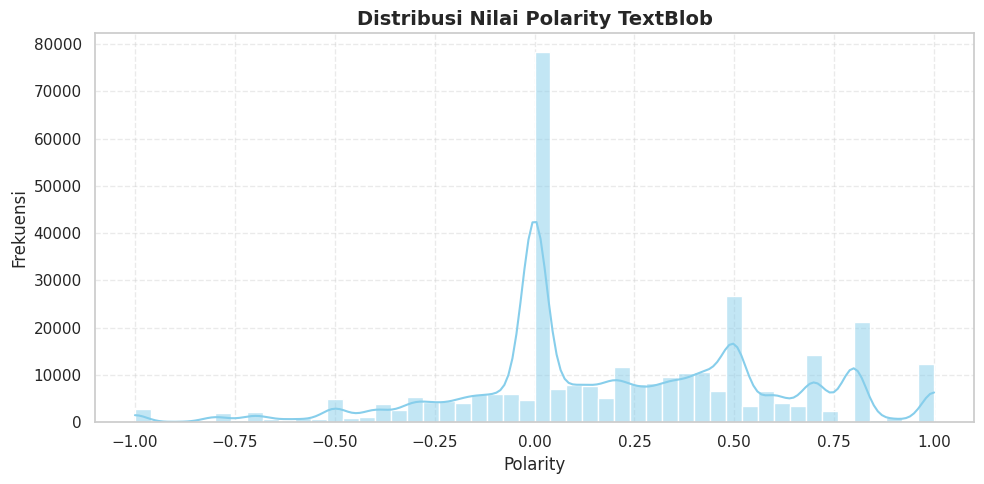

In [15]:
# ============================================================
# DISTRIBUSI POLARITY
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_sentiment,
    x="polarity",
    bins=50,
    kde=True,
    color="skyblue"
)

plt.title("Distribusi Nilai Polarity TextBlob", fontsize=14, fontweight="bold")
plt.xlabel("Polarity")
plt.ylabel("Frekuensi")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

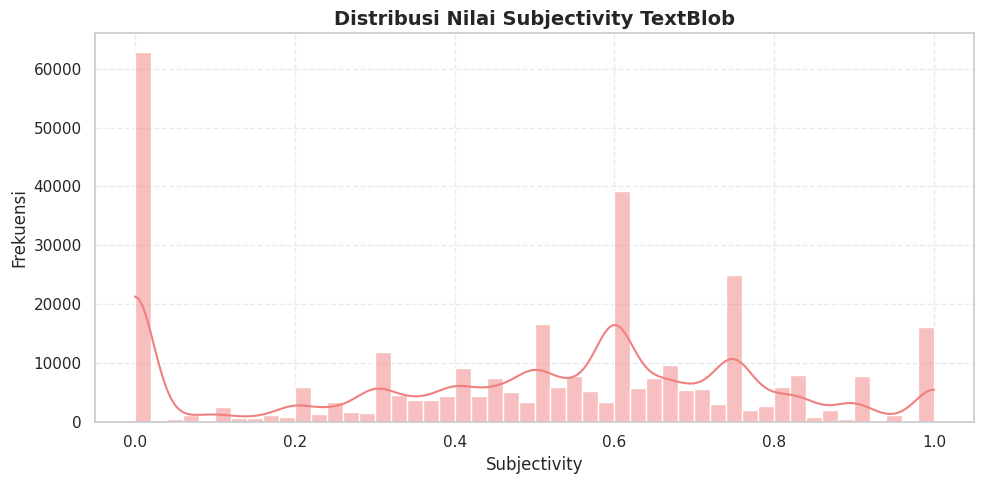

In [16]:
# ============================================================
# DISTRIBUSI SUBJECTIVITY
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_sentiment,
    x="subjectivity",
    bins=50,
    kde=True,
    color="lightcoral"
)

plt.title("Distribusi Nilai Subjectivity TextBlob", fontsize=14, fontweight="bold")
plt.xlabel("Subjectivity")
plt.ylabel("Frekuensi")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

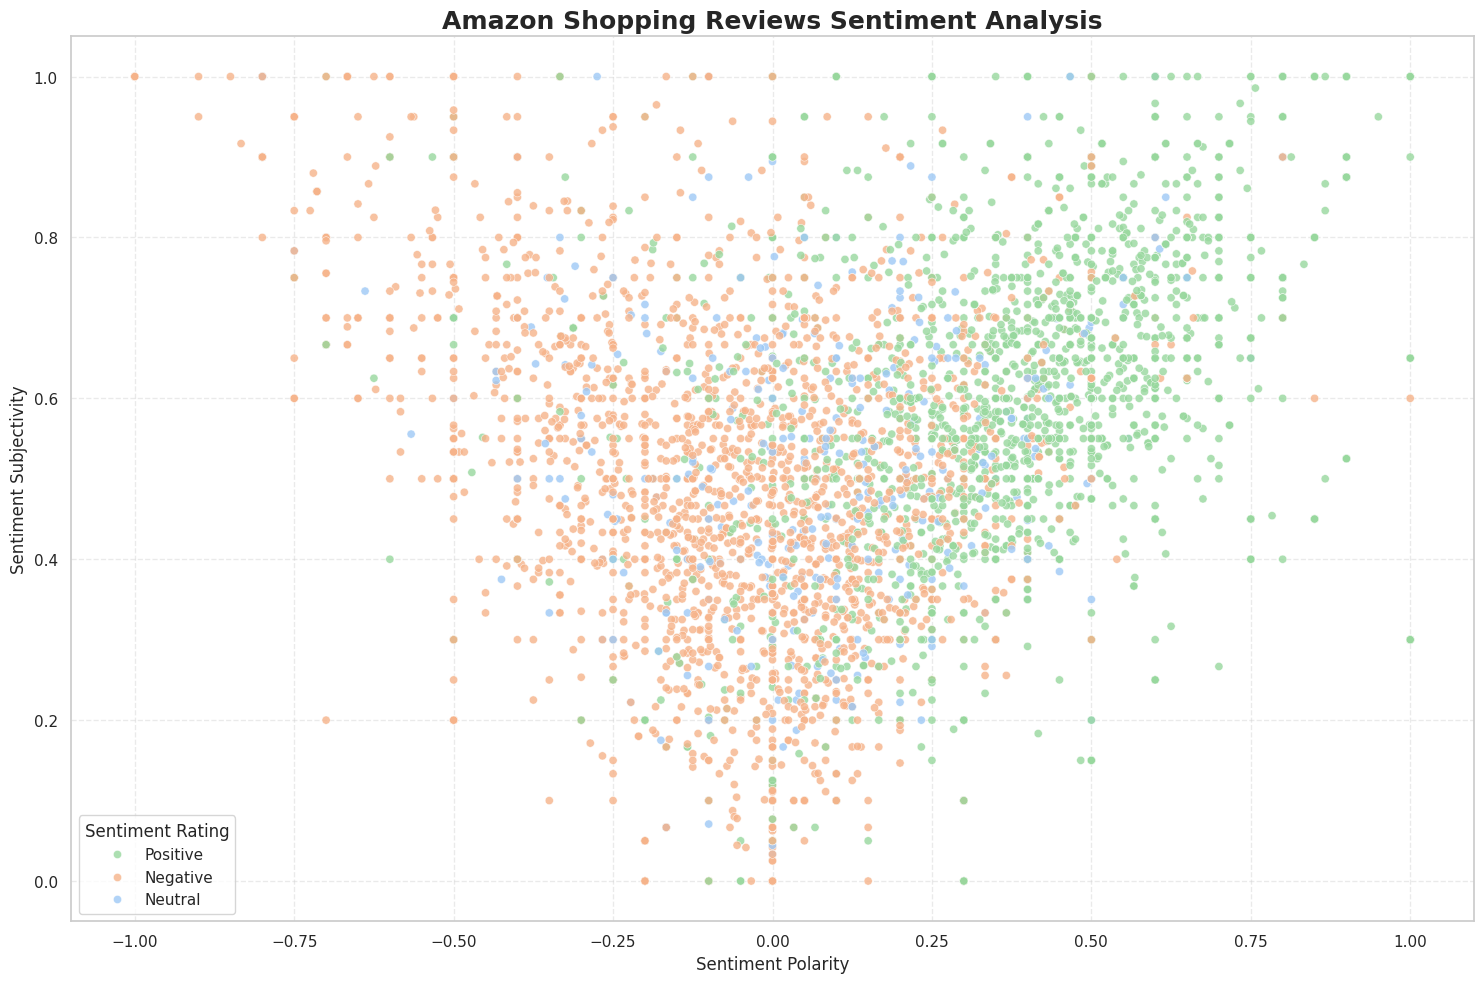

In [48]:
# ============================================================
# SCATTER PLOT POLARITY VS SUBJECTIVITY BERDASARKAN SENTIMENT RATING
# ============================================================

df_plot = df_sentiment.sample(
    n=min(10000, len(df_sentiment)),
    random_state=42
)

plt.figure(figsize=(15, 10))

sns.scatterplot(
    data=df_plot,
    x="polarity",
    y="subjectivity",
    hue="sentiment_rating",
    hue_order=["Positive", "Negative", "Neutral"],
    palette={
        "Positive": "#98D89E",
        "Negative": "#F6B38A",
        "Neutral": "#9EC9F5"
    },
    edgecolor="white",
    linewidth=0.4,
    alpha=0.8,
    s=35
)

plt.title("Amazon Shopping Reviews Sentiment Analysis", fontsize=18, fontweight="bold")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.legend(title="Sentiment Rating")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

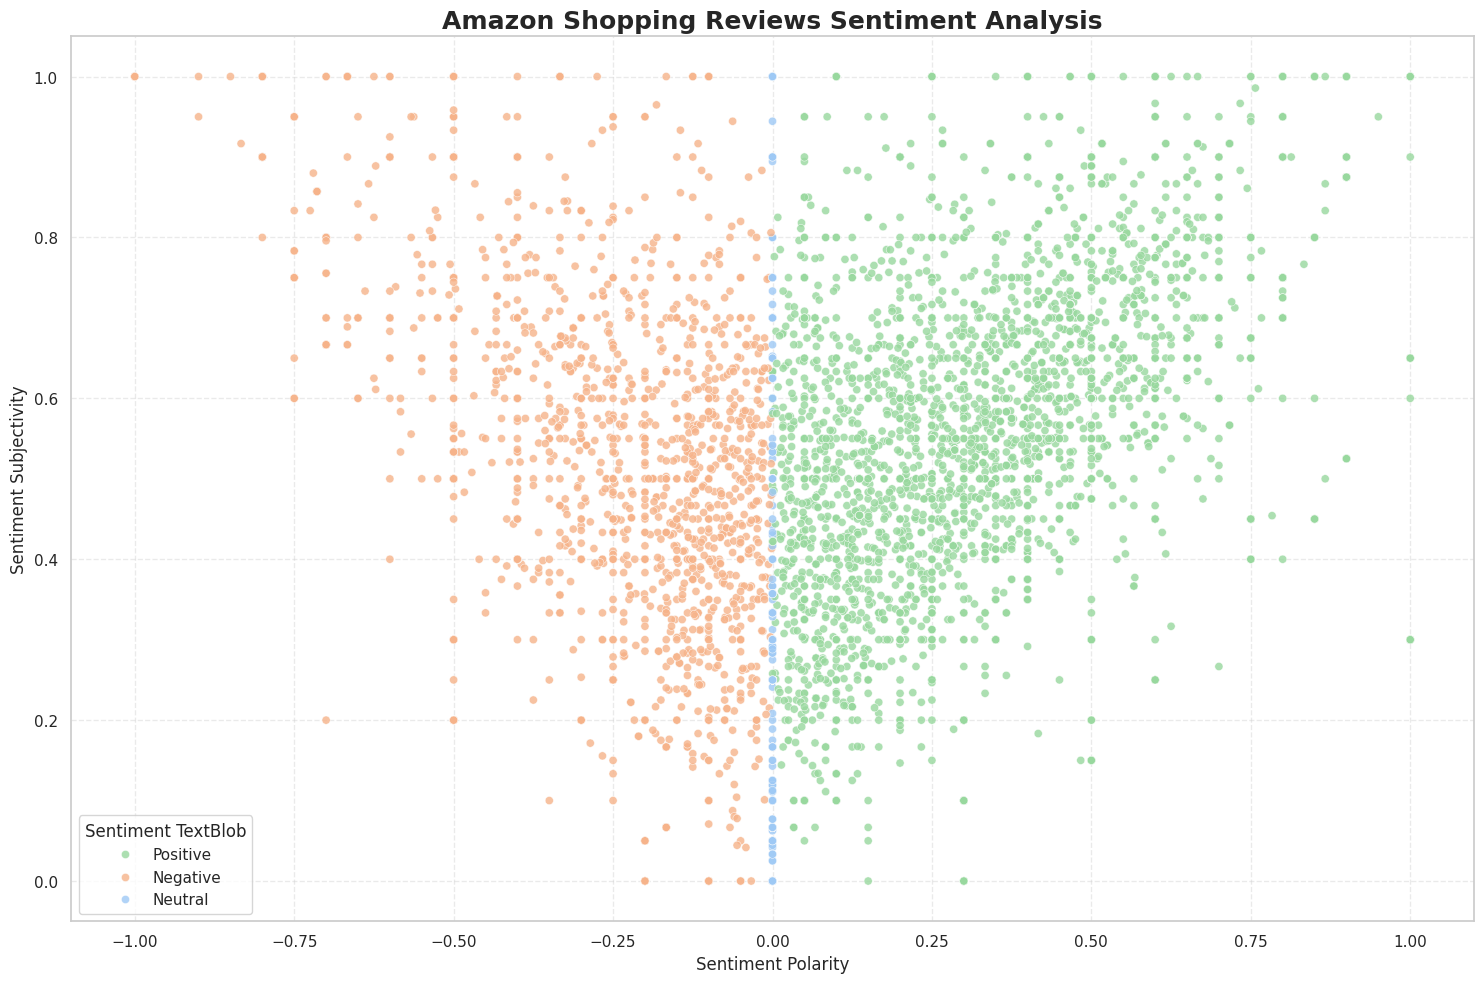

In [51]:
# ============================================================
# SCATTER PLOT POLARITY VS SUBJECTIVITY BERDASARKAN SENTIMENT TEXTBLOB
# ============================================================

df_plot = df_sentiment.sample(
    n=min(10000, len(df_sentiment)),
    random_state=42
)

plt.figure(figsize=(15, 10))

sns.scatterplot(
    data=df_plot,
    x="polarity",
    y="subjectivity",
    hue="sentiment_textblob",
    hue_order=["Positive", "Negative", "Neutral"],
    palette={
        "Positive": "#98D89E",
        "Negative": "#F6B38A",
        "Neutral": "#9EC9F5"
    },
    edgecolor="white",
    linewidth=0.4,
    alpha=0.8,
    s=35
)

plt.title("Amazon Shopping Reviews Sentiment Analysis", fontsize=18, fontweight="bold")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.legend(title="Sentiment TextBlob")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# STATISTIK POLARITY DAN SUBJECTIVITY
# ============================================================

df_sentiment[["polarity", "subjectivity"]].describe()

,polarity,subjectivity
count,332562.000000,332562.000000
mean,0.215838,0.476014
std,0.394662,0.299672
min,-1.000000,0.000000
25%,0.000000,0.267857
50%,0.162219,0.537500
75%,0.500000,0.700000
max,1.000000,1.000000


In [19]:
# ============================================================
# SENTIMEN TEXTBLOB BERDASARKAN RATING
# ============================================================

rating_sentiment = pd.crosstab(
    df_sentiment["score"],
    df_sentiment["sentiment_textblob"]
)

rating_sentiment = rating_sentiment.reindex(columns=sentiment_order, fill_value=0)

rating_sentiment

sentiment_textblob,Positive,Neutral,Negative
score,,,
1,30085,33582,43760
2,9211,6112,8528
3,10115,5533,5509
4,17803,5190,2562
5,127356,22901,4315


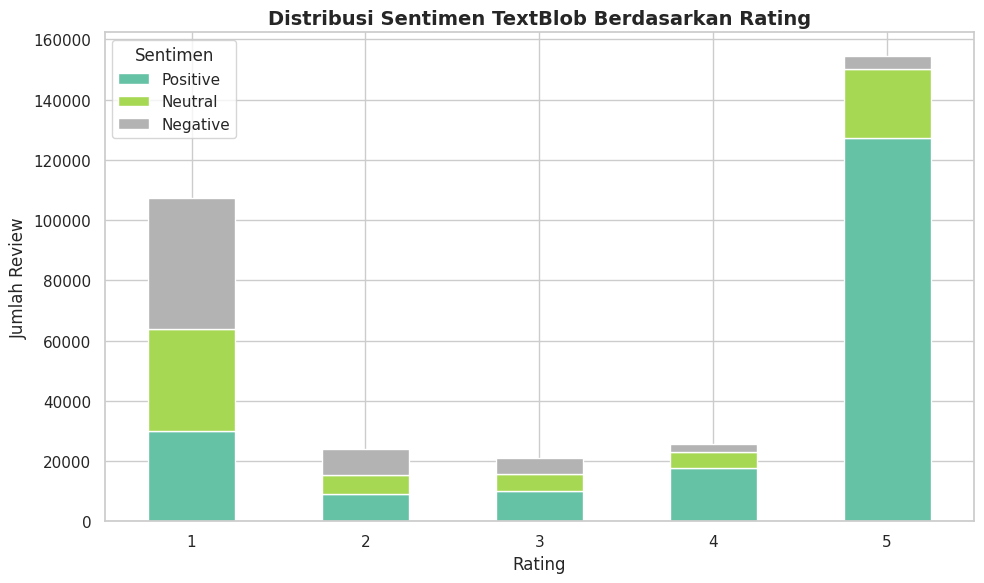

In [20]:
# ============================================================
# VISUALISASI SENTIMEN BERDASARKAN RATING
# ============================================================

rating_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="Set2"
)

plt.title("Distribusi Sentimen TextBlob Berdasarkan Rating", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=0)
plt.legend(title="Sentimen")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# PERBANDINGAN SENTIMEN TEXTBLOB DAN SENTIMEN RATING
# ============================================================

comparison_sentiment = pd.crosstab(
    df_sentiment["sentiment_rating"],
    df_sentiment["sentiment_textblob"]
)

comparison_sentiment = comparison_sentiment.reindex(
    index=sentiment_order,
    columns=sentiment_order,
    fill_value=0
)

comparison_sentiment

sentiment_textblob,Positive,Neutral,Negative
sentiment_rating,,,
Positive,145159,28091,6877
Neutral,10115,5533,5509
Negative,39296,39694,52288


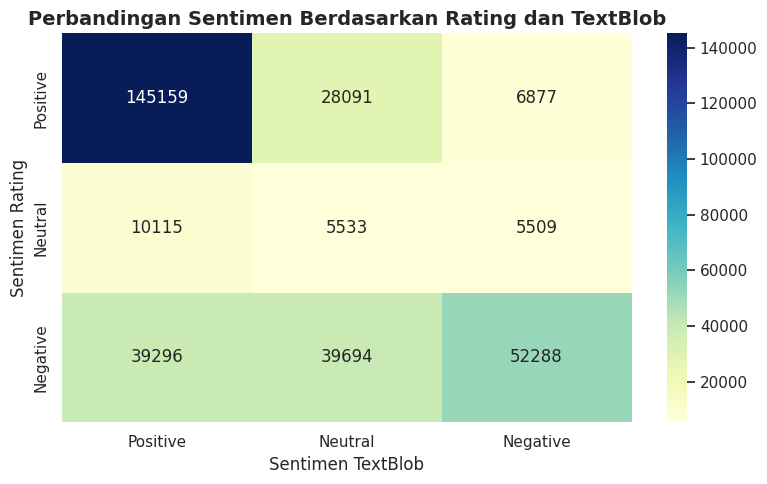

In [22]:
# ============================================================
# HEATMAP PERBANDINGAN SENTIMEN TEXTBLOB DAN RATING
# ============================================================

plt.figure(figsize=(8, 5))

sns.heatmap(
    comparison_sentiment,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Perbandingan Sentimen Berdasarkan Rating dan TextBlob", fontsize=14, fontweight="bold")
plt.xlabel("Sentimen TextBlob")
plt.ylabel("Sentimen Rating")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# RATA-RATA POLARITY BERDASARKAN RATING
# ============================================================

avg_polarity_rating = df_sentiment.groupby("score")["polarity"].mean().reset_index()

avg_polarity_rating

,score,polarity
0,1,-0.072286
1,2,0.001853
2,3,0.084315
3,4,0.295067
4,5,0.454006


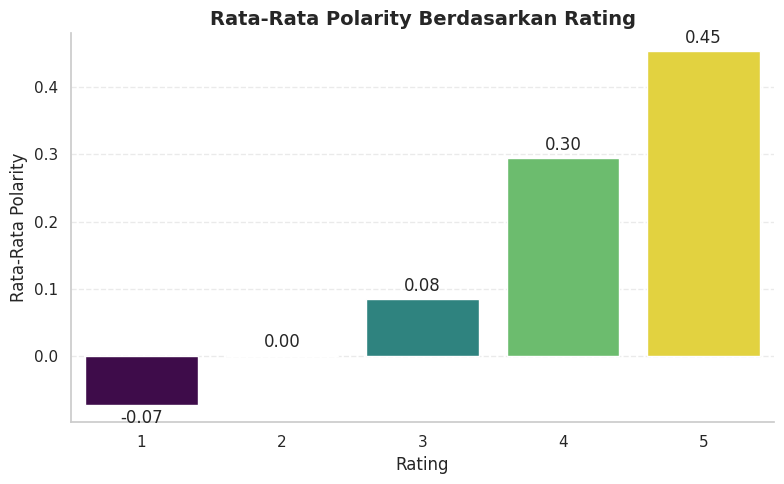

In [24]:
# ============================================================
# VISUALISASI RATA-RATA POLARITY BERDASARKAN RATING
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=avg_polarity_rating,
    x="score",
    y="polarity",
    hue="score",
    palette="viridis",
    legend=False
)

plt.title("Rata-Rata Polarity Berdasarkan Rating", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Rata-Rata Polarity")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# RATA-RATA SUBJECTIVITY BERDASARKAN SENTIMEN
# ============================================================

avg_subjectivity_sentiment = df_sentiment.groupby("sentiment_textblob")["subjectivity"].mean().reindex(sentiment_order)

avg_subjectivity_sentiment

,subjectivity
sentiment_textblob,
Positive,0.602784
Neutral,0.061432
Negative,0.564624


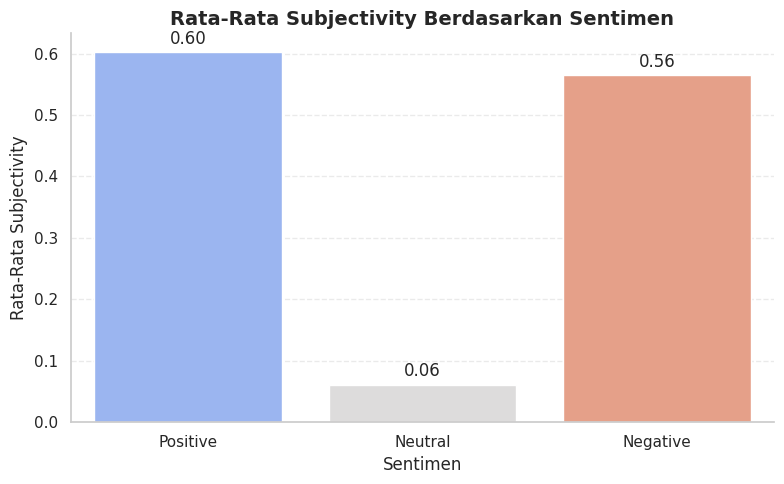

In [26]:
# ============================================================
# VISUALISASI RATA-RATA SUBJECTIVITY BERDASARKAN SENTIMEN
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=avg_subjectivity_sentiment.index,
    y=avg_subjectivity_sentiment.values,
    hue=avg_subjectivity_sentiment.index,
    palette="coolwarm",
    legend=False
)

plt.title("Rata-Rata Subjectivity Berdasarkan Sentimen", fontsize=14, fontweight="bold")
plt.xlabel("Sentimen")
plt.ylabel("Rata-Rata Subjectivity")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CONTOH REVIEW POSITIVE
# ============================================================

df_sentiment[df_sentiment["sentiment_textblob"] == "Positive"][
    ["content", text_column, "score", "polarity", "subjectivity", "sentiment_textblob"]
].sort_values(by="polarity", ascending=False).head(10)

,content,final_clean_text,score,polarity,subjectivity,sentiment_textblob
332509,Works perfectly on both my Moto-G and Samsung ...,work perfectly moto samsung galaxy tablet appr...,5,1.0,1.0,Positive
57,I Get everything on amazon it's the best,get everything best,5,1.0,0.3,Positive
47,Amazon shopping is the best!!!,best,5,1.0,0.3,Positive
332488,Amazon is one of the best merchants to purchas...,one best merchant purchase drive search anothe...,5,1.0,0.3,Positive
332445,Among the best,among best,5,1.0,0.3,Positive
332437,Perfect application,perfect application,5,1.0,1.0,Positive
332396,The best thang smoking,best thang smoking,5,1.0,0.3,Positive
332393,Best place to shop online👍👍,best place shop online,5,1.0,0.3,Positive
332363,It's the best app ever!!!!,best ever,5,1.0,0.3,Positive
332347,Works perfectly. .,work perfectly,5,1.0,1.0,Positive


In [28]:
# ============================================================
# CONTOH REVIEW NEGATIVE
# ============================================================

df_sentiment[df_sentiment["sentiment_textblob"] == "Negative"][
    ["content", text_column, "score", "polarity", "subjectivity", "sentiment_textblob"]
].sort_values(by="polarity").head(10)

,content,final_clean_text,score,polarity,subjectivity,sentiment_textblob
81865,It's one of the worst applications ever. Shame...,one worst application ever shame could fix,1,-1.0,1.0,Negative
149758,My experience with Amazon is awful I ordered s...,experience awful ordered stuff child scamed,1,-1.0,1.0,Negative
204993,Ordered item but didnt delivered And after 1 w...,ordered item delivered week saying delivered w...,1,-1.0,1.0,Negative
51451,Worst customer service ever,worst customer service ever,1,-1.0,1.0,Negative
51459,Worst peple in the world,worst world,1,-1.0,1.0,Negative
51469,"Dreadful, has become unusable. Can't remove it...",dreadful become unusable cannot remove item cart,1,-1.0,1.0,Negative
204896,Miserable. Just want to view my bill and i cant.,miserable want view bill cannot,1,-1.0,1.0,Negative
305487,Do not install it is awful,install awful,1,-1.0,1.0,Negative
97791,Worst return policy ever,worst return policy ever,1,-1.0,1.0,Negative
47209,Delivery is terrible my grandma had ordered a ...,delivery terrible grandma ordered package got ...,1,-1.0,1.0,Negative


In [29]:
# ============================================================
# CONTOH REVIEW NEUTRAL
# ============================================================

df_sentiment[df_sentiment["sentiment_textblob"] == "Neutral"][
    ["content", text_column, "score", "polarity", "subjectivity", "sentiment_textblob"]
].head(10)

,content,final_clean_text,score,polarity,subjectivity,sentiment_textblob
2,app keeps crashing,keep crashing,2,0.0,0.000,Neutral
5,"shopping online with App, card, send to nunu, ...",online card send woo amy boy friend,1,0.0,0.000,Neutral
7,will not install on android 16 tablet! needs f...,install android tablet need fixing use ali exp...,1,0.0,0.000,Neutral
8,need to place a order,need place order,3,0.0,0.000,Neutral
9,since I cannot use this app on my tablet I am ...,since cannot use tablet cancelling prime shop ...,1,0.0,0.000,Neutral
16,i am trying to cancel my amazon prime,trying cancel prime,1,0.0,0.000,Neutral
18,still looking for my icon amazon,still looking icon,5,0.0,0.000,Neutral
19,trying to get into my Amazon account,trying get account,5,0.0,0.000,Neutral
20,"This is Amazon' (say it like, this is amasin' 😆)",say like,5,0.0,0.000,Neutral
22,just needed some help with my account and have...,needed help account repeatedly denied help off...,1,0.0,0.125,Neutral


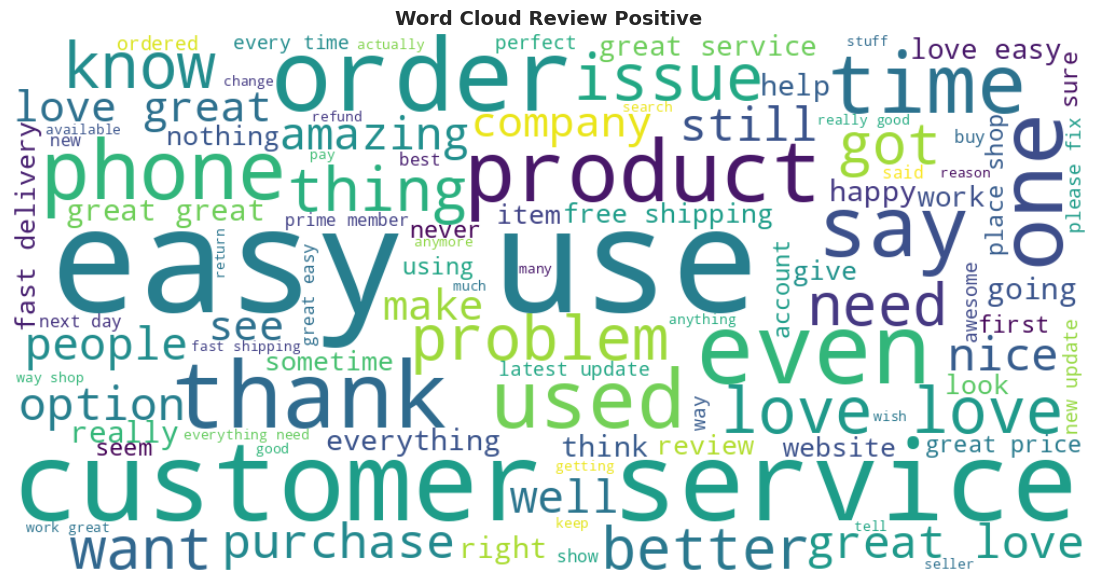

In [40]:
# ============================================================
# WORD CLOUD REVIEW POSITIVE
# ============================================================

positive_text = " ".join(
    df_sentiment[df_sentiment["sentiment_textblob"] == "Positive"][text_column].astype(str)
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Review Positive", fontsize=14, fontweight="bold")
plt.show()

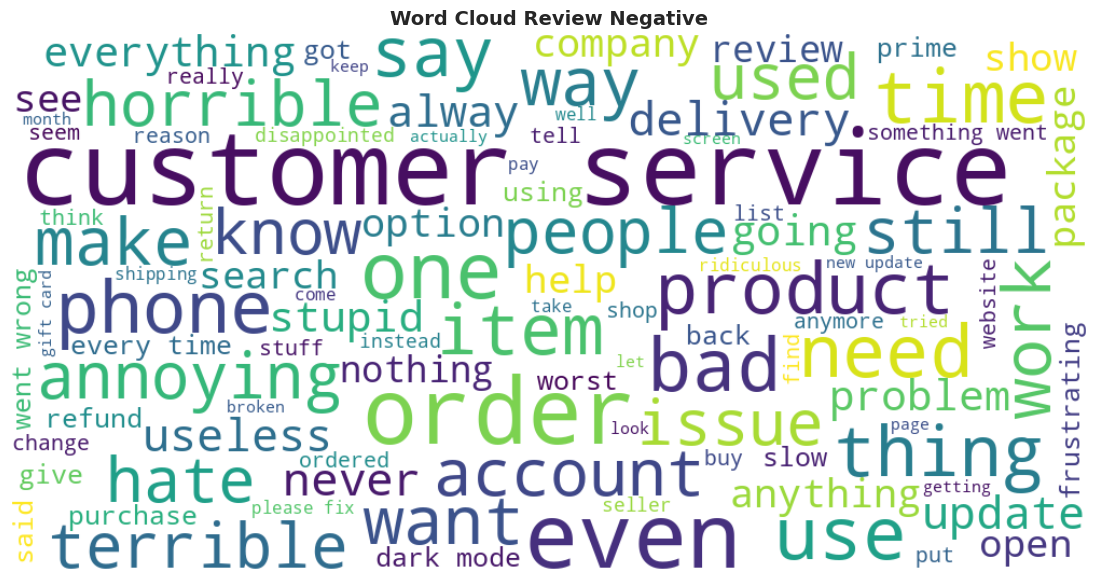

In [39]:
# ============================================================
# WORD CLOUD REVIEW NEGATIVE
# ============================================================

negative_text = " ".join(
    df_sentiment[df_sentiment["sentiment_textblob"] == "Negative"][text_column].astype(str)
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Review Negative", fontsize=14, fontweight="bold")
plt.show()

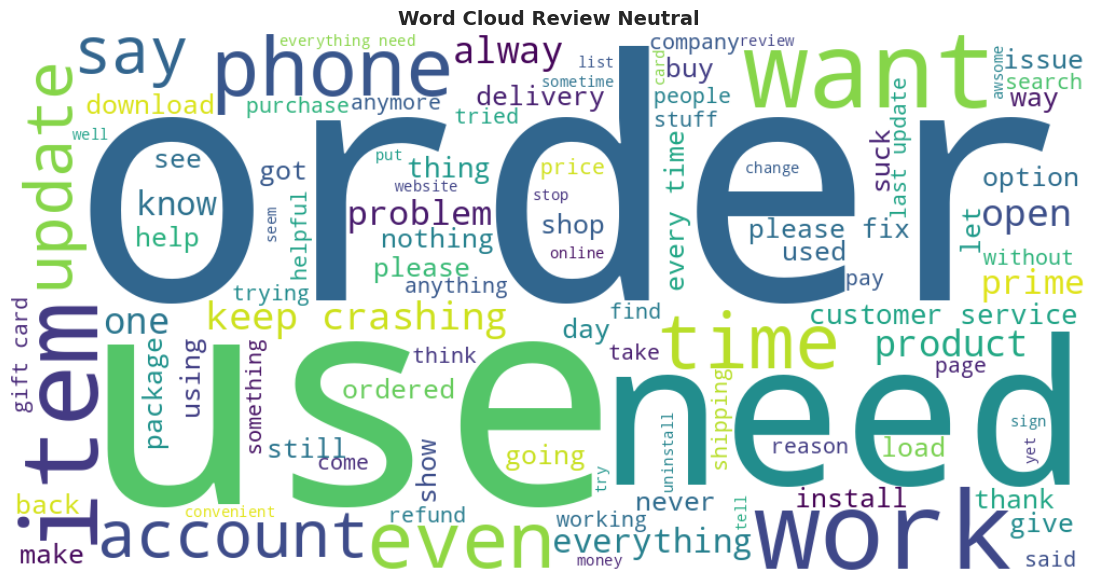

In [41]:
# ============================================================
# WORD CLOUD REVIEW NEUTRAL
# ============================================================

neutral_text = " ".join(
    df_sentiment[df_sentiment["sentiment_textblob"] == "Neutral"][text_column].astype(str)
)

wordcloud_neutral = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(neutral_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Review Neutral", fontsize=14, fontweight="bold")
plt.show()

In [33]:
# ============================================================
# RINGKASAN HASIL SENTIMENT ANALYSIS
# ============================================================

summary = {
    "Jumlah data": df_sentiment.shape[0],
    "Rata-rata polarity": round(df_sentiment["polarity"].mean(), 4),
    "Rata-rata subjectivity": round(df_sentiment["subjectivity"].mean(), 4),
    "Jumlah sentiment positive": sentiment_counts.get("Positive", 0),
    "Jumlah sentiment neutral": sentiment_counts.get("Neutral", 0),
    "Jumlah sentiment negative": sentiment_counts.get("Negative", 0)
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Keterangan", "Nilai"]
)

summary_df

,Keterangan,Nilai
0,Jumlah data,332562.0000
1,Rata-rata polarity,0.2158
2,Rata-rata subjectivity,0.4760
3,Jumlah sentiment positive,194570.0000
4,Jumlah sentiment neutral,73318.0000
5,Jumlah sentiment negative,64674.0000


In [34]:
# ============================================================
# DATASET FINAL YANG DISIMPAN
# ============================================================

final_columns = [
    "reviewId",
    "userName",
    "content",
    "score",
    "thumbsUpCount",
    "reviewCreatedVersion",
    "at",
    "final_clean_text",
    "final_stemmed_text",
    "polarity",
    "subjectivity",
    "sentiment_textblob",
    "sentiment_rating"
]

available_final_columns = [col for col in final_columns if col in df_sentiment.columns]

df_final_sentiment = df_sentiment[available_final_columns].copy()

print("Ukuran dataset final sentiment:")
print(df_final_sentiment.shape)

df_final_sentiment.head()

Ukuran dataset final sentiment:
(332562, 13)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,final_clean_text,final_stemmed_text,polarity,subjectivity,sentiment_textblob,sentiment_rating
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,compatible android tablet lost mind ever made ...,compat android tablet lost mind ever made deci...,-0.112500,0.125000,Negative,Negative
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...,0.100000,0.400000,Positive,Negative
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,keep crashing,keep crash,0.000000,0.000000,Neutral,Negative
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,love got new pixel tablet let install personal...,love got new pixel tablet let instal person th...,0.184091,0.388636,Positive,Neutral
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49,good service,good servic,0.700000,0.600000,Positive,Positive


In [35]:
# ============================================================
# SIMPAN DATASET HASIL SENTIMENT ANALYSIS
# ============================================================

df_final_sentiment.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

print("Dataset hasil sentiment analysis berhasil disimpan sebagai:")
print(OUTPUT_PATH)

Dataset hasil sentiment analysis berhasil disimpan sebagai:
data/amazon_reviews_sentiment.csv


In [36]:
# ============================================================
# DOWNLOAD FILE CSV UNTUK DIUPLOAD KE GITHUB
# ============================================================

from google.colab import files

files.download(OUTPUT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>